In [3]:
import numpy as np

# 1. Load the dataset
# Replace 'your_dataset.npz' with your actual file path
data = np.load('/data2/juve/dataset/vatex/npz_datasets/VATEX_8_frames/train/00cwEcZZcu4_000003_000013.npz')

# 2. List all variables stored in the file
print(f"Keys found in the dataset: {list(data.keys())}")

# 3. Access the first datapoint
# Note: NPZ files usually store arrays. We'll grab the first index [0].
# Adjust the key names ('images', 'captions') based on the output of step 2.
# try:
#     # Assuming standard naming, let's look at the first entry
#     first_images = data['images'][0]
#     first_captions = data['captions'][0]

#     print("\n--- First Datapoint Structure ---")
#     print(f"Images Shape:   {first_images.shape}  (Expected 8 frames)")
#     print(f"Captions Shape: {first_captions.shape} (Expected 10 captions)")
    
#     # 4. Peek at the actual content
#     print("\nFirst Caption Sample:")
#     print(first_captions[0]) 
    
# except KeyError as e:
#     print(f"\nKey Error: Could not find {e}. Check the printed keys above!")
print(data.keys)

Keys found in the dataset: ['arr_0', 'arr_1']


In [4]:
# Check metadata for both arrays
for key in data.keys():
    item = data[key]
    print(f"Key: {key}")
    print(f"  - Shape: {item.shape}")
    print(f"  - Data Type: {item.dtype}")
    print(f"  - First element type: {type(item[0])}")
    print("-" * 20)

Key: arr_0
  - Shape: (8, 3, 224, 224)
  - Data Type: float64
  - First element type: <class 'numpy.ndarray'>
--------------------
Key: arr_1
  - Shape: (10, 1024)
  - Data Type: int64
  - First element type: <class 'numpy.ndarray'>
--------------------


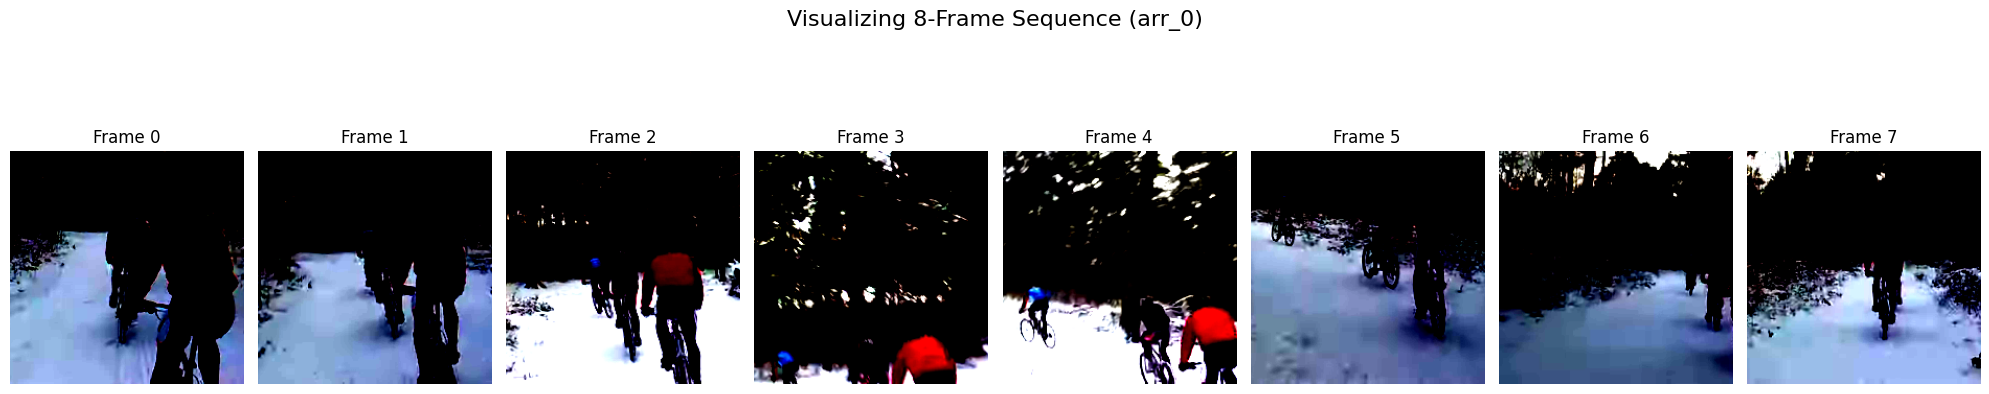


--- Caption Data (arr_1) ---
Number of captions: 10
First 20 tokens of first caption: 
[   32  1402  1448   286   661   389 10311   511 16715   832   262  8222
   326   318  5017   287  6729    13 50256 50256]...


In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Load data (assuming 'data' is already loaded from your np.load)
imgs = data['arr_0']  # Shape (8, 3, 224, 224)
caps = data['arr_1']  # Shape (10, 1024)

# Setup the figure for 8 frames
fig, axes = plt.subplots(1, 8, figsize=(20, 5))
fig.suptitle("Visualizing 8-Frame Sequence (arr_0)", fontsize=16)

for i in range(8):
    # 1. Grab the i-th frame
    frame = imgs[i] 
    
    # 2. Transpose from (3, 224, 224) -> (224, 224, 3)
    frame_to_show = frame.transpose(1, 2, 0)
    
    # 3. Handle Normalization 
    # If values are 0-1 (float64), imshow works fine. 
    # If they are outside that range, we clip for safety.
    frame_to_show = np.clip(frame_to_show, 0, 1)
    
    axes[i].imshow(frame_to_show)
    axes[i].set_title(f"Frame {i}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Inspecting the Caption Tokens
print(f"\n--- Caption Data (arr_1) ---")
print(f"Number of captions: {caps.shape[0]}")
print(f"First 20 tokens of first caption: \n{caps[0][:20]}...")

# YD dataset

In [4]:
import torch
from datasets import load_from_disk
from transformers import AutoTokenizer
from torchvision.transforms.functional import to_pil_image

# ---- PATHS ----
dataset_path = "/data1/juve/datasets/youdescribe/hf_datasets/YD_2.0_v5_v2_gpt4o_captions_full_balanced_dataset_duration_10/arrow/train"

# load dataset
dataset = load_from_disk(dataset_path)

print("Dataset structure:")
print(dataset)

print("\nNumber of samples:", len(dataset))
print("Features:", dataset.features)

# tokenizer for caption decoding
tokenizer = AutoTokenizer.from_pretrained("gpt2")

# get first datapoint
sample = dataset[0]

print("\nKeys in datapoint:", sample.keys())

video_id = sample["videoID"]
pixel_values = sample["pixel_values"]
labels = sample["labels"]

print("\nVideo ID:", video_id)

# convert to tensor if needed
if not isinstance(pixel_values, torch.Tensor):
    pixel_values = torch.tensor(pixel_values)

print("Pixel values shape:", pixel_values.shape)

# decode captions
print("\nDecoded captions:")
for i, caption_tokens in enumerate(labels):
    caption = tokenizer.decode(caption_tokens, skip_special_tokens=True)
    print(f"{i+1}: {caption}")

# optional: save image for visual check
try:
    if pixel_values.dim() == 4:
        frame = pixel_values[0]
    else:
        frame = pixel_values

    img = to_pil_image(frame)
    img.save("debug_first_frame.png")
    print("\nSaved first frame to debug_first_frame.png")

except Exception as e:
    print("\nImage conversion failed:", e)

Dataset structure:
Dataset({
    features: ['videoID', 'pixel_values', 'labels'],
    num_rows: 43302
})

Number of samples: 43302
Features: {'videoID': Value(dtype='string', id=None), 'pixel_values': Sequence(feature=Sequence(feature=Sequence(feature=Sequence(feature=Value(dtype='float32', id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None), length=-1, id=None), 'labels': Sequence(feature=Sequence(feature=Value(dtype='int64', id=None), length=-1, id=None), length=-1, id=None)}

Keys in datapoint: dict_keys(['videoID', 'pixel_values', 'labels'])

Video ID: 5z_d0soK1cI_000439_000449.
Pixel values shape: torch.Size([8, 3, 224, 224])

Decoded captions:
1: A chef expertly demonstrates knife skills to a group of attentive students. He brings the knife down in a precise, rhythmic chopping motion while his fingers are safely tucked away.
2: The chef shows proper knife-handling techniques to students. His fingers are folded under as he chops food swiftly and confidently, cr

## Check Test Set outputs with Juve

In [14]:
import pandas as pd

rows = []

# with open("/data2/juve/training_artifacts/psc_stuff/training_artifacts/VATEX-psc_ref_run_ws16_nc10_ss1.0_enl12_dnl12_dhs768_ehs768_nf8_ps16_lr5e-07_bs16_rs42/VATEX-psc_ref_run_ws16_nc10_ss1.0_enl12_dnl12_dhs768_ehs768_nf8_ps16_lr5e-07_bs16_rs42.csv", "r") as f:
with open("/data2/juve/training_artifacts/psc_stuff/VATEX-psc_eager_attn_ws16_nc10_ep20_ss1.0_enl12_dnl16_dhs768_ehs768_nf8_ps16_lr5e-07_bs512_rs42/VATEX-psc_eager_attn_ws16_nc10_ep20_ss1.0_enl12_dnl16_dhs768_ehs768_nf8_ps16_lr5e-07_bs512_rs42.csv", "r") as f:
    header = f.readline().strip().split(",")

    for line in f:
        parts = line.strip().split(",", 3)  # split only first 3 commas
        if len(parts) == 4:
            rows.append(parts)

df = pd.DataFrame(rows, columns=header)

In [2]:
bad_rows = []

with open("/data2/juve/training_artifacts/psc_stuff/training_artifacts/VATEX-psc_ref_run_ws16_nc10_ss1.0_enl12_dnl12_dhs768_ehs768_nf8_ps16_lr5e-07_bs16_rs42/VATEX-psc_ref_run_ws16_nc10_ss1.0_enl12_dnl12_dhs768_ehs768_nf8_ps16_lr5e-07_bs16_rs42.csv", "r") as f:
    header = f.readline()

    for i, line in enumerate(f, start=2):  # line numbers start at 2
        comma_count = line.count(",")

        # expected minimum = 3 commas (uid, filename, pred, gt)
        if comma_count > 3:
            # possible issue → pred OR gt has commas
            parts = line.strip().split(",", 3)

            if len(parts) < 4:
                bad_rows.append((i, "split_failed", line.strip()))
                continue

            uid, filename, pred, gt = parts

            # check if pred itself still contains commas
            if "," in pred:
                bad_rows.append((i, "comma_in_pred", pred))

print(f"Found {len(bad_rows)} problematic rows")
for row in bad_rows[:10]:
    print(row)

Found 0 problematic rows


In [15]:
df.head()

,uid,filename,pred,gt
0,--SIRvUHMTc_000000_000010.npz::0,--SIRvUHMTc_000000_000010.npz,A person is swimming in the water and then fal...,A person is trying to water ski being pulled b...
1,-0eFCgzIWFk_000001_000011.npz::0,-0eFCgzIWFk_000001_000011.npz,A man is riding a unicycle on a sidewalk and t...,A boy climbs on top of a unicycle and then bou...
2,-0sNYhpevoU_000000_000010.npz::0,-0sNYhpevoU_000000_000010.npz,A person is using their hands to make a face w...,A person with black hair is shown massaging hi...
3,-12MxdP5uVo_000004_000014.npz::0,-12MxdP5uVo_000004_000014.npz,A man is welding a piece of metal with a weldi...,A welder dressed in protective gear welds a lo...
4,-1ZGHXvwuas_000346_000356.npz::0,-1ZGHXvwuas_000346_000356.npz,A man is playing a game of hide and seek with ...,A boy wearing a mask tries to fling playing ca...


In [16]:
for idx, row in df.iterrows():
    predicted_captions = [row['pred']]
    ground_truth_captions = [[c.strip()] for c in row['gt'].split("||")]
    print(f"predicted_captions: {predicted_captions}\nground_truth_captions: {ground_truth_captions}")
    break

predicted_captions: ['A person is swimming in the water and then falls off.']
ground_truth_captions: [['A person is trying to water ski being pulled by a boat.'], ['A person stands up then immediately falls on water skis.'], ['A person is sailing behind a motor boat that is treading across the water.'], ['A man waterskies before falling into the water as his friend records.'], ['A person is starting to waterski behind a boat and then wipes out.'], ['A woman is being pulled up on a set of skis while a boat is pulling her on a lake.'], ['A man is water skiing while being pulled by a boat in the ocean.'], ['A person is on water skis behind a boat, which stops when the person falls into the water.'], ['A water skier is being pulled behind a boat and being splashed with the water.'], ['A person is water skiing getting pulled by a boat.']]


In [17]:
predicted_captions = []
ground_truth_captions = []

for idx, row in df.iterrows():

    predicted_captions.append(row['pred'])
    # ground_truth_captions.append([[c.strip()] for c in row['gt'].split("||") if c.strip()])
    ground_truth_captions.append(
        [c.strip() for c in row['gt'].split("||") if c.strip()]
    )



In [6]:
len(predicted_captions)

5295

In [7]:
len(ground_truth_captions)

5295

In [11]:
print(ground_truth_captions[:1])

[['A person is trying to water ski being pulled by a boat.', 'A person stands up then immediately falls on water skis.', 'A person is sailing behind a motor boat that is treading across the water.', 'A man waterskies before falling into the water as his friend records.', 'A person is starting to waterski behind a boat and then wipes out.', 'A woman is being pulled up on a set of skis while a boat is pulling her on a lake.', 'A man is water skiing while being pulled by a boat in the ocean.', 'A person is on water skis behind a boat, which stops when the person falls into the water.', 'A water skier is being pulled behind a boat and being splashed with the water.', 'A person is water skiing getting pulled by a boat.']]


In [20]:
from model_tools.metrics import calculate_scores

cider_score, _, ciderD_score, _, bleu_score, _, meteor_score, _, rouge_score, _, spice_score, _ = calculate_scores(predicted_captions, ground_truth_captions)
bleu_1_score, bleu_2_score, bleu_3_score, bleu_4_score = bleu_score

metrics_dict = {}
metrics_dict["blue1_score"] = bleu_1_score
metrics_dict["blue2_score"] = bleu_2_score
metrics_dict["blue3_score"] = bleu_3_score
metrics_dict["blue4_score"] = bleu_4_score
metrics_dict["cider_score"] = cider_score
metrics_dict["ciderD_score"] = ciderD_score
metrics_dict["meteor_score"] = meteor_score
metrics_dict["rouge_score"] = rouge_score
metrics_dict["spice_score"] = spice_score

PTBTokenizer tokenized 875801 tokens at 2563455.28 tokens per second.
PTBTokenizer tokenized 79446 tokens at 671746.63 tokens per second.


/home/917160535/TimesGPT
/home/917160535/TimesGPT
{'testlen': 68863, 'reflen': 68309, 'guess': [68863, 63568, 58273, 52978], 'correct': [49562, 26009, 12785, 5378]}
ratio: 1.0081102050974102


Parsing reference captions
Parsing test captions


SPICE evaluation took: 10.37 s


In [21]:
metrics_dict

{'blue1_score': 0.719718862088484,
 'blue2_score': 0.5426552334860731,
 'blue3_score': 0.40126115201726786,
 'blue4_score': 0.28457821206517325,
 'cider_score': 0.6188758176062825,
 'ciderD_score': 0.4845390886348076,
 'meteor_score': 0.22002283893658806,
 'rouge_score': 0.4763384164508282,
 'spice_score': 0.09308243732725852}

{'blue1_score': 0.719718862088484,
 'blue2_score': 0.5426552334860731,
 'blue3_score': 0.40126115201726786,
 'blue4_score': 0.28457821206517325,
 'cider_score': 0.6188758176062825,
 'ciderD_score': 0.4845390886348076,
 'meteor_score': 0.22002283893658806,
 'rouge_score': 0.4763384164508282,
 'spice_score': 0.09308243732725852}